Connected to ni-vedo-env (Python 3.14.0)

 # Notebook 03: Tissue thickness mapping

 **Paper section:** Results — The cranial neural tube maintains a
 dorso-ventral thickness gradient
 **Paper figures:** Fig. 5

 This script quantifies local tissue thickness by measuring the Euclidean
 distance from each vertex on the **basal (outer) surface** mesh to the
 nearest face of the **lumen (inner) surface** mesh.

 **Output:** `basal-thickness.npy` — array of shape (N, 4) with columns
 X, Y, Z, thickness (µm).

In [1]:
from vedo import settings
settings.default_backend = "vtk"

from spatchcocking import *
import os
import numpy as np

 ## Parameters

In [2]:
# --- Input meshes ---
inner_path = "../data/example/lumen.ply"   # inner (lumen) surface
outer_path = "../data/example/basal.ply"   # outer (basal lamina) surface

# --- Output ---
npy_file = "../data/example/basal-thickness.npy"

 ## Load meshes

In [3]:
s1 = Mesh(inner_path)   # inner (lumen)
s2 = Mesh(outer_path)   # outer (basal)

show(s1, s2.alpha(0.5)).close()

vedo.plotter.runtime.Plotter
n. of objects : 2 (6706 vertices)
bounds        : x=(139, 1.91e+3), y=(645, 3.35e+3), z=(1.35e+3, 4.92e+3)
axes style    : [None]

 ## Compute thickness

 `distance_to(s1, signed=False)` computes, for each vertex of `s2` (outer),
 the unsigned distance to the nearest face of `s1` (inner).
 This equals the local wall thickness between the two surfaces.

In [4]:
run_computation = True

if os.path.exists(npy_file):
    answer = input(f"'{npy_file}' already exists. Rerun thickness analysis? [y/N]: ")
    run_computation = answer.strip().lower() == "y"

if run_computation:
    s2.distance_to(s1, signed=False)   # stores result in s2.pointdata["Distance"]
    s2.cmap("hot").add_scalarbar("Thickness (µm)")
    print("Thickness computation done.")
else:
    # Load from cache and restore to mesh
    # cols: X  Y  Z  thickness
    data = np.load(npy_file)
    s2.pointdata["Distance"] = data[:, 3]
    s2.cmap("hot", input_array="Distance").add_scalarbar("Thickness (µm)")
    print(f"Loaded thickness from {npy_file}")

Loaded thickness from ../data/example/basal-thickness.npy


In [5]:
pts    = s2.vertices
values = s2.pointdata["Distance"]

print(f"Thickness: min={values.min():.1f} µm, "
      f"max={values.max():.1f} µm, "
      f"mean={values.mean():.1f} µm")

Thickness: min=0.6 µm, max=139.2 µm, mean=68.1 µm


 ## Save thickness data

In [6]:
if run_computation:
    thicknessdata = np.column_stack((pts, values))   # (N, 4): X Y Z thickness
    np.save(npy_file, thicknessdata)
    print(f"Saved: {npy_file}  shape={thicknessdata.shape}")

 ## Visualize on basal mesh

In [7]:
# Interpolate thickness from the point cloud onto the basal mesh for display
points = Points(pts, r=5).cmap("hot", values)
s2.interpolate_data_from(points, n=5).cmap("hot", vmin=0).add_scalarbar()
show([s2, points], N=2, axes=9).close()

vedo.plotter.runtime.Plotter
n. of objects : 4 (7546 vertices)
bounds        : x=(139, 1.91e+3), y=(645, 3.35e+3), z=(1.35e+3, 4.92e+3)
axes style    : 9 (the bounding box outline)

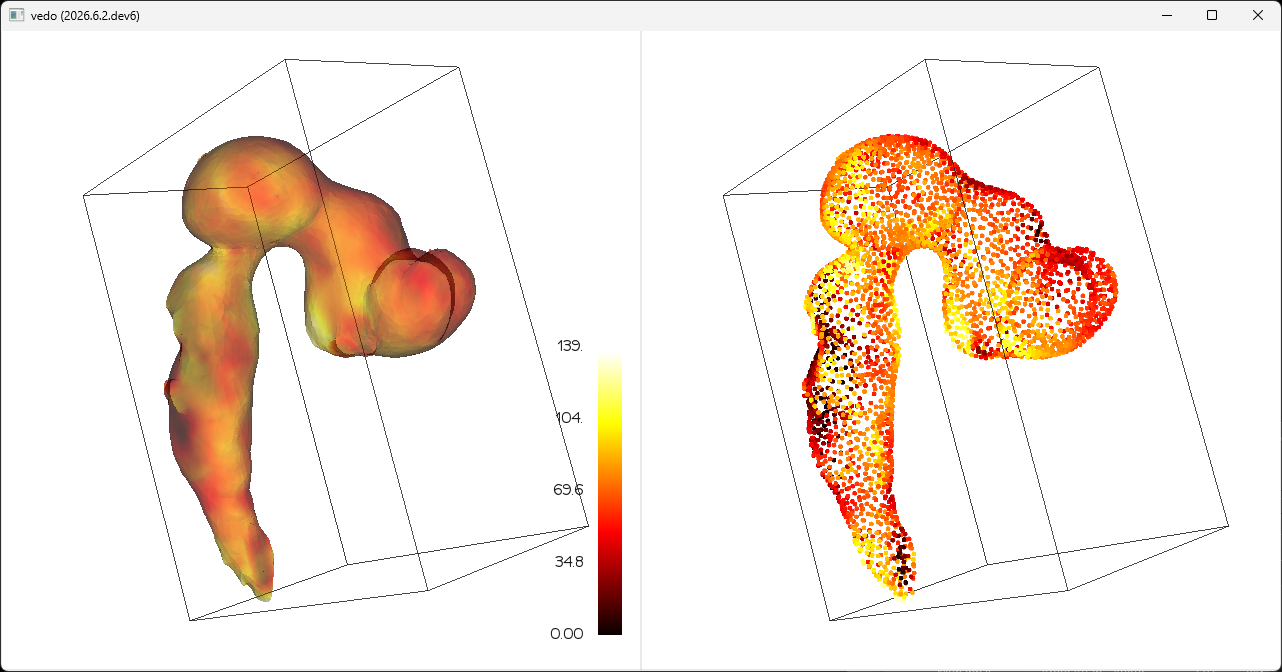